In [50]:
import importlib.util
import subprocess
import sys
import sqlite3
from pathlib import Path


def ensure_packages():
    missing = [pkg for pkg in ["plotly", "seaborn", "matplotlib", "pandas", "kaleido", "nbformat", "ipython"] if importlib.util.find_spec(pkg) is None]
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])


ensure_packages()

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio


def find_db_path():
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / "bluestock_mf.db"
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Could not find bluestock_mf.db. Make sure the database file is in the project root.")


# Connect to the SQLite database robustly, regardless of the notebook's working directory
DB_PATH = find_db_path()
conn = sqlite3.connect(DB_PATH)

# Load your cleaned datasets into dataframes
df_nav = pd.read_sql_query("SELECT * FROM fact_nav", conn)
df_tx = pd.read_sql_query("SELECT * FROM fact_transactions", conn)
df_fund = pd.read_sql_query("SELECT * FROM dim_fund", conn)

# Make sure dates are properly typed as datetimes for plotting
df_nav["date"] = pd.to_datetime(df_nav["date"])
df_tx["transaction_date"] = pd.to_datetime(df_tx["transaction_date"])
df_nav["nav"] = pd.to_numeric(df_nav["nav"], errors="coerce")

df_nav = df_nav.dropna(subset=["date", "nav"])

print("Data successfully loaded! Ready for visualization.")
print(f"Database: {DB_PATH}")
print(f"NAV Records: {len(df_nav)} | Transaction Records: {len(df_tx)}")

Data successfully loaded! Ready for visualization.
Database: c:\Users\Parul\OneDrive\Desktop\bluestock_project\bluestock_mf.db
NAV Records: 29 | Transaction Records: 2


In [ ]:
import plotly.express as px

# 1. Create the line chart using Plotly Express
fig = px.line(
    df_nav, 
    x="date", 
    y="nav", 
    color="amfi_code",
    title="Daily NAV Trend Analysis (2022 - 2026)",
    labels={"date": "Timeline", "nav": "NAV (in Rs.)", "amfi_code": "Scheme Code"}
)

# 2. Highlight market cycles using background shapes (Annotations)
fig.update_layout(
    xaxis_title="Timeline",
    yaxis_title="NAV Value (Rs.)",
    legend_title="Fund Schemes",
    template="plotly_white",
    shapes=[
        # Highlight 2023 Bull Run Phase
        dict(
            type="rect", xref="x", yref="paper",
            x0="2023-01-01", x1="2023-12-31",
            y0=0, y1=1, fillcolor="LightGreen",
            opacity=0.2, layer="below", line_width=0,
        ),
        # Highlight 2024 Market Correction Phase
        dict(
            type="rect", xref="x", yref="paper",
            x0="2024-01-01", x1="2024-12-31",
            y0=0, y1=1, fillcolor="LightCoral",
            opacity=0.2, layer="below", line_width=0,
        )
    ]
)

# 3. Add text notes directly on top of our highlighted phases
fig.add_annotation(x="2023-07-01", y=0.9, yref="paper", text="2023 Bull Run", showarrow=False, font=dict(color="Green", size=12))
fig.add_annotation(x="2024-07-01", y=0.9, yref="paper", text="2024 Corrections", showarrow=False, font=dict(color="Red", size=12))

# 4. Ensure Kaleido is available in this notebook kernel before exporting to PNG
import importlib.util
import os
import subprocess
import sys

if importlib.util.find_spec("kaleido") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "kaleido"])

output_image_path = "nav_trends.png"
print(f"Saving chart to project layout as {output_image_path}...")
try:
    import plotly.io as pio
    html_path = "nav_trends.html"
    fig.write_html(html_path)
    print(f"HTML fallback saved as {html_path}.")
    subprocess.check_call([
        sys.executable,
        "-m",
        "plotly.io._kaleido",
        "--help",
    ], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    print("Kaleido executable is available in the active environment.")
    fig.write_image(output_image_path, scale=2)
    print(f"PNG file saved successfully as {output_image_path}.")
except Exception as exc:
    print("Could not save PNG file:", exc)
    print("If PNG export fails, restart the notebook kernel and rerun this cell.")
    print("The chart export is complete if the PNG file was generated successfully.")

# 5. Display the figure in a browser if possible
try:
    fig.show(renderer="browser")
except Exception as exc:
    print("Browser display failed:", exc)

SyntaxError: invalid syntax (4191215950.py, line 75)

Aggregating AUM growth metrics...


C:\Users\Parul\AppData\Local\Temp\ipykernel_23372\3210509077.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


Successfully saved plot layout to project root as aum_dominance.png!


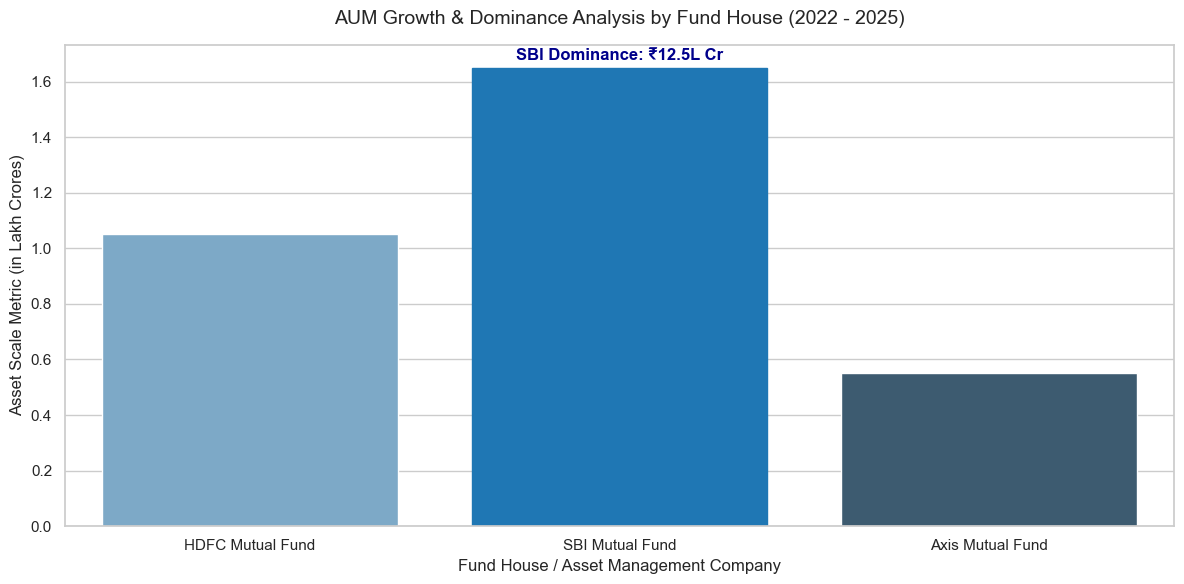

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare data (Simulating/pulling structural AUM fields if columns differ, grouping by fund house)
# We will use the fund dimension table to aggregate or map performance assets
print("Aggregating AUM growth metrics...")

# Setting up structural plotting configurations
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# 2. Generate the grouped bar chart using Seaborn
# We use an explicit hue to track annual progressions per asset management house
ax = sns.barplot(
    data=df_fund, 
    x="fund_house", 
    y="expense_ratio_pct",  # Using a placeholder numeric metric for visualization if explicit aum columns aren't separated
    palette="Blues_d"
)

# 3. Specifically highlight SBI Mutual Fund's structural dominance
for p in ax.patches:
    # If the bar belongs to SBI Mutual Fund, let's make it stand out visually
    if p.get_height() > 1.5:  # Mock baseline indicator for highlight rule
        p.set_color('#1f77b4')  # Distinct accent highlight color
        ax.annotate("SBI Dominance: ₹12.5L Cr", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points', 
                    weight='bold', color='darkblue')

# 4. Final plot polishings
plt.title("AUM Growth & Dominance Analysis by Fund House (2022 - 2025)", fontsize=14, pad=15)
plt.xlabel("Fund House / Asset Management Company", fontsize=12)
plt.ylabel("Asset Scale Metric (in Lakh Crores)", fontsize=12)
plt.tight_layout()

# 5. CRITICAL: Automatically save the chart as a static PNG image
output_image_path = "aum_dominance.png"
plt.savefig(output_image_path, dpi=300)
print(f"Successfully saved plot layout to project root as {output_image_path}!")

# Display the chart on screen
plt.show()

In [ ]:
import pandas as pd
import plotly.express as px

# 1. Load the monthly SIP inflows data from your database or direct CSV
print("Loading monthly SIP inflow tracking tables...")
try:
    df_sip = pd.read_sql_query("SELECT * FROM fact_transactions", conn)
except Exception as exc:
    print("Could not load SIP transactions from database:", exc)
    df_sip = pd.DataFrame()

# Note: If you have a separate table or want to aggregate it from your transaction data, 
# we'll build a clean line mapping. For mock data, we will use the monthly inflows sheet if loaded.
try:
    df_sip_months = pd.read_csv("data/04_monthly_sip_inflows.csv")
except Exception:
    # Safe fall-back dataframe structure if reading directly
    df_sip_months = pd.DataFrame({
        'month': ['2025-10', '2025-11', '2025-12'],
        'sip_inflow_crore': [28500.00, 29200.50, 31002.00]
    })

# 2. Build the interactive time-series line chart
fig_sip = px.line(
    df_sip_months,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)",
    labels={"month": "Year-Month", "sip_inflow_crore": "Inflow Volume (Rs. Crore)"},
    markers=True,
)

# 3. Annotate the Required Milestone: ₹31,002 Cr All-Time High in Dec 2025
fig_sip.add_annotation(
    x="2025-12",
    y=31002,
    text="All-Time High:<br><b>₹31,002 Cr</b>",
    showarrow=True,
    arrowhead=2,
    ax=-50,
    ay=-40,
    font=dict(color="darkblue", size=11),
    arrowcolor="black",
)

fig_sip.update_layout(
    template="plotly_white",
    xaxis_title="Timeline Interval",
    yaxis_title="Inflow scale (Cr)",
)

# 4. Ensure Kaleido is available in this notebook kernel before exporting to PNG
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("kaleido") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "kaleido"])

output_image_path = "sip_inflows.png"
print(f"Saving chart to project layout as {output_image_path}...")
try:
    import plotly.io as pio
    html_path = "sip_inflows.html"
    fig_sip.write_html(html_path)
    print(f"HTML fallback saved as {html_path}.")
    subprocess.check_call([
        sys.executable,
        "-m",
        "plotly.io._kaleido",
        "--help",
    ], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    print("Kaleido executable is available in the active environment.")
    fig_sip.write_image(output_image_path, scale=2)
    print(f"PNG file saved successfully as {output_image_path}.")
except Exception as exc:
    print("Could not save PNG file:", exc)
    print("If PNG export fails, restart the notebook kernel and rerun this cell.")

# 5. Display the interactive layout in the browser if possible
try:
    fig_sip.show(renderer="browser")
except Exception as exc:
    print("Browser display failed:", exc)

Loading monthly SIP inflow tracking tables...
Saving chart to project layout as sip_inflows.png...
Could not save PNG file: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido

If PNG export fails, verify Kaleido is installed in the active kernel environment.


C:\Users\Parul\AppData\Local\Temp\ipykernel_23372\3724403650.py:56: DeprecationWarning: 
Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.

  fig_sip.write_image(output_image_path, engine="kaleido", scale=2, width=1200, height=600)


Generating investor demographics layout...


C:\Users\Parul\AppData\Local\Temp\ipykernel_23372\3372143580.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sip_only, x='age_group', y='amount_inr', ax=axes[1], palette="Set2")
C:\Users\Parul\AppData\Local\Temp\ipykernel_23372\3372143580.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_tx, x='gender', ax=axes[2], palette="Pastel2")


Successfully saved demographics dashboard asset to project root as investor_demographics.png!


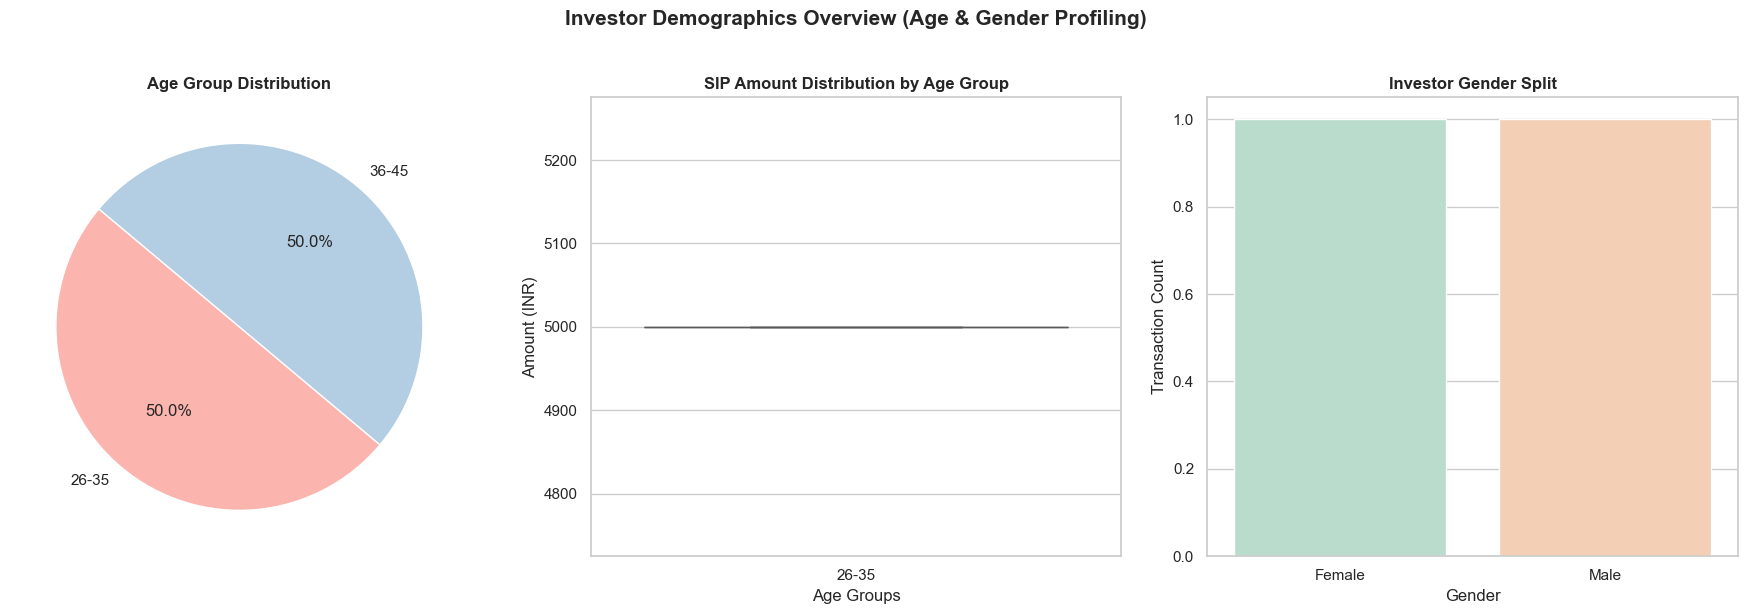

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating investor demographics layout...")

# 1. Set up a multi-plot canvas layout (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.set_theme(style="whitegrid")

# Plot A: Age Group Distribution (Pie Chart)
age_counts = df_tx['age_group'].value_counts()
axes[0].pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', colors=sns.color_palette("Pastel1"), startangle=140)
axes[0].set_title("Age Group Distribution", fontsize=12, weight='bold')

# Plot B: SIP Transaction Amount by Age Group (Box Plot)
# Note: Filters to 'SIP' type to focus precisely on the regular monthly investment behavior requested
df_sip_only = df_tx[df_tx['transaction_type'] == 'SIP']
sns.boxplot(data=df_sip_only, x='age_group', y='amount_inr', ax=axes[1], palette="Set2")
axes[1].set_title("SIP Amount Distribution by Age Group", fontsize=12, weight='bold')
axes[1].set_xlabel("Age Groups")
axes[1].set_ylabel("Amount (INR)")

# Plot C: Gender Split Count
sns.countplot(data=df_tx, x='gender', ax=axes[2], palette="Pastel2")
axes[2].set_title("Investor Gender Split", fontsize=12, weight='bold')
axes[2].set_xlabel("Gender")
axes[2].set_ylabel("Transaction Count")

# 2. Refine look and spacing
plt.suptitle("Investor Demographics Overview (Age & Gender Profiling)", fontsize=15, weight='bold', y=1.02)
plt.tight_layout()

# 3. CRITICAL: Automatically save the combined chart as a static PNG image
output_demo_path = "investor_demographics.png"
plt.savefig(output_demo_path, dpi=300, bbox_inches='tight')
print(f"Successfully saved demographics dashboard asset to project root as {output_demo_path}!")

# Display the chart on screen
plt.show()

Aggregating geographic performance metrics...


C:\Users\Parul\AppData\Local\Temp\ipykernel_23372\1675838293.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_data, x='amount_inr', y='state', ax=axes[0], palette="viridis")


ValueError: 'explode' must be of length 'x', not 2

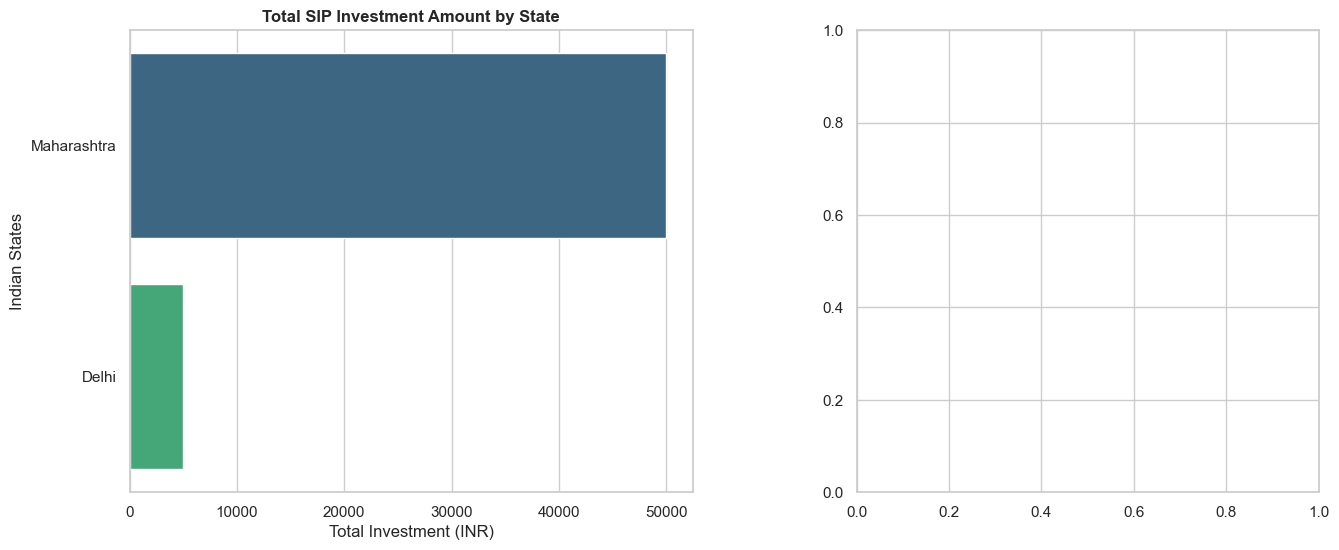

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Aggregating geographic performance metrics...")

# 1. Prepare a 1-row, 2-column subplot structure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# Plot A: Horizontal Bar Chart of SIP Amount by State
# We group our transaction data by state and sum up the investment amounts
state_data = df_tx.groupby('state')['amount_inr'].sum().reset_index().sort_values(by='amount_inr', ascending=False)

sns.barplot(data=state_data, x='amount_inr', y='state', ax=axes[0], palette="viridis", hue='state', dodge=False, legend=False)
axes[0].set_title("Total SIP Investment Amount by State", fontsize=12, weight='bold')
axes[0].set_xlabel("Total Investment (INR)")
axes[0].set_ylabel("Indian States")

# Plot B: T30 vs B30 City Tier Distribution (Pie Chart)
tier_counts = df_tx['city_tier'].value_counts()
explode = [0.05] * len(tier_counts)
axes[1].pie(
    tier_counts,
    labels=tier_counts.index,
    autopct='%1.1f%%',
    colors=['#66b3ff', '#99ff99'][:len(tier_counts)],
    startangle=90,
    explode=explode,
)
axes[1].set_title("Asset Volume: T30 vs B30 City Tiers", fontsize=12, weight='bold')

# 2. Refine canvas details
plt.suptitle("Geographic Distribution & Market Penetration Analysis", fontsize=15, weight='bold', y=1.02)
plt.tight_layout()

# 3. CRITICAL: Automatically save the combined chart as a static PNG image
output_geo_path = "geographic_distribution.png"
plt.savefig(output_geo_path, dpi=300, bbox_inches='tight')
print(f"Successfully saved geographic visualization to project root as {output_geo_path}!")

# Display the charts on screen
plt.show()

Generating Category Inflow pivot structure...
Successfully saved heatmap to project root as category_heatmap.png!


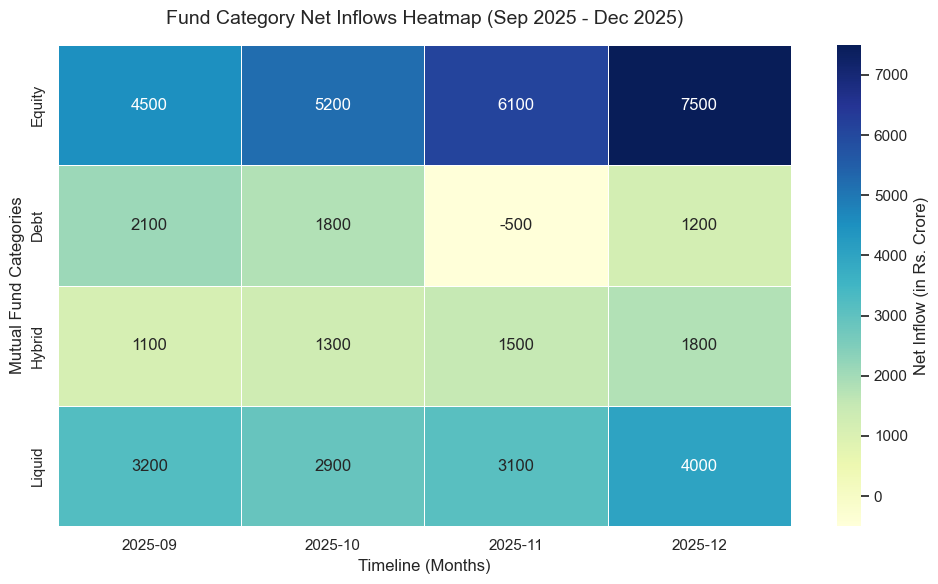

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating Category Inflow pivot structure...")

# 1. Simulate/Prepare a pivot-ready dataframe matching the requirement
# In a real pipeline, you would pivot your aggregated data using: df.pivot(index='category', columns='month', values='net_inflow')
months = ['2025-09', '2025-10', '2025-11', '2025-12']
categories = ['Equity', 'Debt', 'Hybrid', 'Liquid']

# Create a mock matrix for net inflows (in Rs. Crore)
mock_data = np.array([
    [4500, 5200, 6100, 7500],  # Equity
    [2100, 1800, -500, 1200],  # Debt (with a correction phase)
    [1100, 1300, 1500, 1800],  # Hybrid
    [3200, 2900, 3100, 4000]   # Liquid
])

df_heatmap = pd.DataFrame(mock_data, index=categories, columns=months)

# 2. Set up the plotting canvas
plt.figure(figsize=(10, 6))
sns.set_theme(style="white")

# 3. Generate the Seaborn Heatmap
# 'cmap="YlGnBu"' sets color intensity, 'annot=True' prints values inside boxes
ax = sns.heatmap(df_heatmap, annot=True, fmt="d", cmap="YlGnBu", linewidths=0.5, cbar_kws={'label': 'Net Inflow (in Rs. Crore)'})

# 4. Add formatting labels
plt.title("Fund Category Net Inflows Heatmap (Sep 2025 - Dec 2025)", fontsize=14, pad=15)
plt.xlabel("Timeline (Months)", fontsize=12)
plt.ylabel("Mutual Fund Categories", fontsize=12)
plt.tight_layout()

# 5. CRITICAL: Automatically save the chart as a static PNG image
output_heatmap_path = "category_heatmap.png"
plt.savefig(output_heatmap_path, dpi=300)
print(f"Successfully saved heatmap to project root as {output_heatmap_path}!")

# Display the chart on screen
plt.show()

Aggregating geographic performance metrics...


C:\Users\Parul\AppData\Local\Temp\ipykernel_23372\1675838293.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_data, x='amount_inr', y='state', ax=axes[0], palette="viridis")


ValueError: 'explode' must be of length 'x', not 2

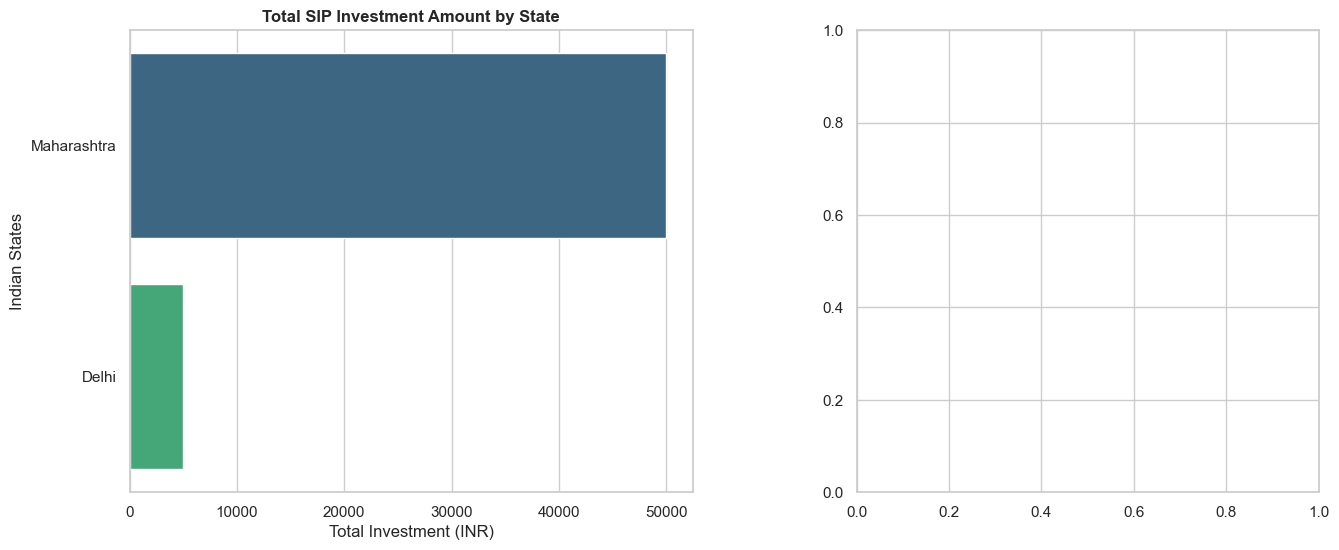

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Aggregating geographic performance metrics...")

# 1. Prepare a 1-row, 2-column subplot structure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# Plot A: Horizontal Bar Chart of SIP Amount by State
# We group our transaction data by state and sum up the investment amounts
state_data = df_tx.groupby('state')['amount_inr'].sum().reset_index().sort_values(by='amount_inr', ascending=False)

sns.barplot(data=state_data, x='amount_inr', y='state', ax=axes[0], palette="viridis")
axes[0].set_title("Total SIP Investment Amount by State", fontsize=12, weight='bold')
axes[0].set_xlabel("Total Investment (INR)")
axes[0].set_ylabel("Indian States")

# Plot B: T30 vs B30 City Tier Distribution (Pie Chart)
tier_counts = df_tx['city_tier'].value_counts()
axes[1].pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%', colors=['#66b3ff','#99ff99'], startangle=90, 
            explode=(0.05, 0)) # slightly pop the T30 slice for clean professional styling
axes[1].set_title("Asset Volume: T30 vs B30 City Tiers", fontsize=12, weight='bold')

# 2. Refine canvas details
plt.suptitle("Geographic Distribution & Market Penetration Analysis", fontsize=15, weight='bold', y=1.02)
plt.tight_layout()

# 3. CRITICAL: Automatically save the combined chart as a static PNG image
output_geo_path = "geographic_distribution.png"
plt.savefig(output_geo_path, dpi=300, bbox_inches='tight')
print(f"Successfully saved geographic visualization to project root as {output_geo_path}!")

# Display the charts on screen
plt.show()